# 08 — TP3: Clasificación de `riesgo_alto`

Predecir si un hexágono H3 es de **riesgo alto de incendio**
(`riesgo_alto = n_focos > 150`) a partir de **8 predictoras ambientales**,
sin usar ninguna variable de fuego. Es un problema **binario y desbalanceado**:
271 positivos sobre 1981 hexágonos (**13.68 %**).

Contenido:

- **B.** Clasificadores: piso trivial (`Dummy`) + `LogReg`, `DecisionTree`,
  `KNN`, `SVC`.
- **C.** Evaluación completa (accuracy, precision/recall/F1 por clase y
  *weighted*, matrices de confusión, `classification_report`, ROC-AUC,
  Precision-Recall + AUC-PR, Kappa) y por qué *accuracy engaña* aquí.
- **D.1.** Clustering K-Means **sólo** sobre las 8 ambientales (sin variables
  de fuego, a diferencia del flujo de Minería).
- **D.2.** Ensambles (`RandomForest`, `XGBoost`) contra los individuales.
- **Extensiones:** análisis de umbral, importancias/coeficientes y
  estabilidad multi-semilla.

Fuente: `data/processed/patagonia_ia.csv` (1981 filas, ya sin el cuadrante de
flaring de Vaca Muerta). Todo el preprocesamiento vive dentro de un `Pipeline`;
se reutiliza `src/` (se extendió `src/modelos.py` con las utilidades de
clasificación).

In [1]:
import sys
import warnings
from pathlib import Path

RAIZ = Path.cwd()
proj = RAIZ if (RAIZ / "src").exists() else RAIZ.parent
sys.path.insert(0, str(proj))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve,
                             silhouette_score, davies_bouldin_score)

from src.data import cargar_dataset, preparar_features
from src import modelos as M

# El parámetro probability=True de SVC quedó deprecado en sklearn 1.9 pero el
# enunciado lo pide explícitamente; silenciamos sólo ese aviso.
warnings.filterwarnings("ignore", message=".*probability.*parameter was deprecated.*")

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
RSTATE = 42
np.random.seed(RSTATE)
print("Proyecto:", proj)

Proyecto: C:\Users\juanc\OneDrive\Desktop\PatagonIA\PatagonIA


## A. Datos y target

`preparar_features` devuelve `X` (7 numéricas + `cobertura_veg` sin encodear =
**8 predictoras**) y el target binario `riesgo_alto = (n_focos > 150)`. La
imputación del único nulo (`elevacion`) y el escalado **no** se hacen aquí:
viven dentro del `Pipeline` y se aprenden sólo con el fold de entrenamiento.

In [2]:
df = cargar_dataset(str(proj / "data" / "processed" / "patagonia_ia.csv"))
X, y_cont, y = preparar_features(df)   # y == riesgo_alto (0/1)

print("X:", X.shape, "| y:", y.shape)
print("Predictoras (8):", list(X.columns))
print("\nNulos en X:")
print(X.isna().sum()[X.isna().sum() > 0].to_string() or "  (ninguno)")
print("\nDistribución del target riesgo_alto = (n_focos > 150):")
print(y.value_counts().rename({0: "bajo (0)", 1: "alto (1)"}).to_string())
print(f"\npositivos = {int(y.sum())}  ({100 * y.mean():.2f} %)"
      f"  ->  prevalencia = {y.mean():.4f}")

X: (1981, 8) | y: (1981,)
Predictoras (8): ['elevacion', 'temp_media', 'precip_anual', 'viento_medio', 'humedad_relativa', 'dist_asentamiento_km', 'dist_ruta_km', 'cobertura_veg']

Nulos en X:
elevacion    1

Distribución del target riesgo_alto = (n_focos > 150):
riesgo_alto
bajo (0)    1710
alto (1)     271

positivos = 271  (13.68 %)  ->  prevalencia = 0.1368


### A.1 Verificación anti-fuga (CRÍTICO)

El target se **deriva** de `n_focos`, así que incluirlo en `X` sería fuga
directa (predeciríamos el objetivo con sí mismo). Y todas las variables de
fuego (`brillo_*`, `frp_*`, `pct_*`, `n_anios_activo`, `mes_pico`) son
**efecto** del incendio, no causa: describen fuegos ya ocurridos, no
condiciones ambientales previas. Verificamos explícitamente que **ninguna**
esté en `X`.

In [3]:
COLS_FUEGO = ["n_focos", "brillo_medio", "brillo_max", "frp_medio", "frp_max",
              "brillo_t31_medio", "pct_noche", "pct_verano", "pct_conf_alta",
              "n_anios_activo", "mes_pico", "brillo", "frp"]

fugas = [c for c in COLS_FUEGO if c in X.columns]
assert not fugas, f"FUGA DETECTADA: {fugas} presentes en X"
assert "n_focos" not in X.columns, "n_focos NO puede estar en X"

# X debe ser EXACTAMENTE las 8 predictoras ambientales:
esperadas = M.NUMERICAS + [M.CATEGORICA]
assert list(X.columns) == esperadas, f"X inesperado: {list(X.columns)}"

print("OK — sin fuga. X contiene sólo las 8 predictoras ambientales:")
for c in X.columns:
    print(f"  - {c}")
print("\nninguna variable de fuego presente en X:", not fugas)

OK — sin fuga. X contiene sólo las 8 predictoras ambientales:
  - elevacion
  - temp_media
  - precip_anual
  - viento_medio
  - humedad_relativa
  - dist_asentamiento_km
  - dist_ruta_km
  - cobertura_veg

ninguna variable de fuego presente en X: True


## A.2 Partición

- `train_test_split` **80/20**, `stratify=y`, `random_state=42` (mantiene la
  prevalencia de 13.68 % en ambos lados: sin estratificar, con 271 positivos,
  el test podría quedar con muy pocos).
- `StratifiedKFold(5, shuffle=True, random_state=42)` sobre train para la
  validación cruzada de los `GridSearchCV` (cada fold conserva la proporción de
  clases).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RSTATE)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RSTATE)

print(f"train: {X_train.shape[0]} filas | test: {X_test.shape[0]} filas")
print(f"positivos train: {int(y_train.sum())} ({100 * y_train.mean():.2f} %)")
print(f"positivos test : {int(y_test.sum())} ({100 * y_test.mean():.2f} %)")

# Razón de desbalance para XGBoost (scale_pos_weight): negativos / positivos.
SPW = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight (neg/pos en train) = {SPW:.3f}")

train: 1584 filas | test: 397 filas
positivos train: 217 (13.70 %)
positivos test : 54 (13.60 %)

scale_pos_weight (neg/pos en train) = 6.300


## B. Clasificadores

**Estrategia común frente al desbalance**

- Todos los modelos que lo soportan usan `class_weight='balanced'`, que pondera
  cada clase por el inverso de su frecuencia (el positivo pesa ~6.3×). Sin
  esto, casi cualquier modelo colapsa a la clase mayoritaria (como el `Dummy`).
- La búsqueda de hiperparámetros (`GridSearchCV`) optimiza **`average_precision`
  (AUC-PR)**, no accuracy: bajo 13.68 % de positivos, accuracy premia predecir
  siempre "bajo"; AUC-PR mide la calidad del *ranking* de la clase de interés.

**Hiperparámetros por modelo (grillas y justificación)**

| Modelo | Se fija | Se busca (grilla) | Por qué |
|---|---|---|---|
| `Dummy` | `strategy='most_frequent'` | — | Piso trivial: define el "accuracy sin modelo". |
| `LogisticRegression` | `class_weight='balanced'`, `max_iter=2000` | `C ∈ {0.01, 0.1, 1, 10}` | `C` regula la fuerza de regularización L2 (frontera lineal). |
| `DecisionTree` | `class_weight='balanced'` | `max_depth ∈ {3,5,7,None}`, `min_samples_leaf ∈ {1,5,20}` | Controlan la complejidad; hojas grandes evitan memorizar. |
| `KNN` | — (no admite `class_weight`) | `n_neighbors ∈ {5,11,21,31}`, `weights ∈ {uniform, distance}` | `k` es el sesgo-varianza; `distance` pondera vecinos cercanos. |
| `SVC` | `class_weight='balanced'`, `probability=True` | `C ∈ {0.1,1,10}`, `gamma ∈ {scale, 0.1}` | `C`/`gamma` definen margen y curvatura del kernel RBF. |

In [5]:
dummy = M.construir_pipeline_clf(DummyClassifier(strategy="most_frequent"))

# (estimador base, grilla) — el prefijo 'model__' apunta al paso del Pipeline.
config = {
    "LogReg": (
        LogisticRegression(class_weight="balanced", max_iter=2000,
                           random_state=RSTATE),
        {"model__C": [0.01, 0.1, 1.0, 10.0]},
    ),
    "DecisionTree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=RSTATE),
        {"model__max_depth": [3, 5, 7, None],
         "model__min_samples_leaf": [1, 5, 20]},
    ),
    "KNN": (
        KNeighborsClassifier(),
        {"model__n_neighbors": [5, 11, 21, 31],
         "model__weights": ["uniform", "distance"]},
    ),
    "SVC": (
        SVC(class_weight="balanced", probability=True, random_state=RSTATE),
        {"model__C": [0.1, 1.0, 10.0], "model__gamma": ["scale", 0.1]},
    ),
}

mejores = {}
for nombre, (est, grid) in config.items():
    gs = GridSearchCV(M.construir_pipeline_clf(est), grid,
                      scoring="average_precision", cv=skf, n_jobs=-1)
    gs.fit(X_train, y_train)
    mejores[nombre] = gs.best_estimator_
    print(f"{nombre:14s} AUC-PR(cv)={gs.best_score_:.4f}  ->  {gs.best_params_}")

LogReg         AUC-PR(cv)=0.3808  ->  {'model__C': 0.1}
DecisionTree   AUC-PR(cv)=0.5117  ->  {'model__max_depth': None, 'model__min_samples_leaf': 20}


KNN            AUC-PR(cv)=0.5577  ->  {'model__n_neighbors': 31, 'model__weights': 'distance'}


SVC            AUC-PR(cv)=0.5463  ->  {'model__C': 1.0, 'model__gamma': 'scale'}


Los parámetros elegidos por CV se documentan arriba. Nota temprana: el árbol
prefiere `min_samples_leaf=20` (poda el sobreajuste) y KNN prefiere `k=31` con
`weights='distance'` — un `k` alto para no sobre-reaccionar a la clase rara.

In [6]:
# Diccionario ordenado de todos los clasificadores de la Sección B.
clasificadores = {
    "Dummy": dummy,
    "LogReg": mejores["LogReg"],
    "DecisionTree": mejores["DecisionTree"],
    "KNN": mejores["KNN"],
    "SVC": mejores["SVC"],
}
print("Clasificadores a evaluar:", list(clasificadores))

Clasificadores a evaluar: ['Dummy', 'LogReg', 'DecisionTree', 'KNN', 'SVC']


## C. Evaluación

Entrenamos cada modelo y calculamos el panel completo en **train y test**
(`src.modelos.evaluar_clasificador`). Métricas de la clase positiva
(`riesgo_alto=1`, la de interés) y *weighted* (ponderada por soporte), más
ROC-AUC, AUC-PR y Kappa de Cohen.

In [7]:
ORDEN_COLS = [
    "test_accuracy", "test_precision_pos", "test_recall_pos", "test_f1_pos",
    "test_f1_w", "test_roc_auc", "test_ap", "test_kappa",
    "train_accuracy", "train_f1_pos", "train_ap",
]

resultados = {}
for nombre, modelo in clasificadores.items():
    resultados[nombre] = M.evaluar_clasificador(
        modelo, X_train, y_train, X_test, y_test)

tabla = pd.DataFrame(resultados).T
modelos_fit = {n: resultados[n]["_modelo"] for n in resultados}   # reutilizar
tabla_comp = tabla.drop(columns=["_modelo"])[ORDEN_COLS]
tabla_comp.style.format("{:.4f}").background_gradient(
    subset=["test_f1_pos", "test_ap", "test_kappa"], cmap="Greens")

,test_accuracy,test_precision_pos,test_recall_pos,test_f1_pos,test_f1_w,test_roc_auc,test_ap,test_kappa,train_accuracy,train_f1_pos,train_ap
Dummy,0.8640,0.0000,0.0000,0.0000,0.8009,0.5000,0.1360,0.0000,0.8630,0.0000,0.1370
LogReg,0.7280,0.2891,0.6852,0.4066,0.7668,0.7604,0.4215,0.2662,0.7008,0.4148,0.3775
DecisionTree,0.8413,0.4563,0.8704,0.5987,0.8600,0.8884,0.6952,0.5116,0.7904,0.5414,0.6571
KNN,0.9043,1.0000,0.2963,0.4571,0.8808,0.8773,0.6985,0.4211,1.0000,1.0000,1.0000
SVC,0.8136,0.4000,0.7407,0.5195,0.8347,0.8690,0.6271,0.4164,0.7759,0.5090,0.6238


### C.1 Por qué accuracy engaña aquí

Mirá la fila `Dummy`: predice **siempre "bajo"** y aun así saca
**accuracy ≈ 0.864** — más alto que `LogReg` o `SVC`. Pero su
`recall_pos = precision_pos = f1_pos = 0`, su `ROC-AUC = 0.5` (azar) y su
`kappa = 0` (nada por encima del azar). Es decir: **no detecta un solo
hexágono de riesgo alto** y aún así "gana" en accuracy.

La razón es el desbalance: con 13.68 % de positivos, la regla trivial "todo
negativo" acierta el 86.32 % de las veces. Por eso, en este problema, las
métricas que importan son las **enfocadas en la clase positiva** (recall/F1),
el **AUC-PR** (cuya línea base es la prevalencia 0.136, no 0.5) y el **Kappa**
(corrige por acuerdo esperado al azar). La `accuracy` sólo se reporta para
exhibir su propia trampa.

In [8]:
# classification_report por clase (precision/recall/F1 de 0 y 1) por modelo.
for nombre, modelo in modelos_fit.items():
    y_pred = modelo.predict(X_test)
    print(f"\n===== {nombre} — classification_report (test) =====")
    print(classification_report(y_test, y_pred,
                                target_names=["bajo (0)", "alto (1)"],
                                zero_division=0, digits=3))


===== Dummy — classification_report (test) =====
              precision    recall  f1-score   support

    bajo (0)      0.864     1.000     0.927       343
    alto (1)      0.000     0.000     0.000        54

    accuracy                          0.864       397
   macro avg      0.432     0.500     0.464       397
weighted avg      0.746     0.864     0.801       397


===== LogReg — classification_report (test) =====
              precision    recall  f1-score   support

    bajo (0)      0.937     0.735     0.824       343
    alto (1)      0.289     0.685     0.407        54

    accuracy                          0.728       397
   macro avg      0.613     0.710     0.615       397
weighted avg      0.849     0.728     0.767       397


===== DecisionTree — classification_report (test) =====
              precision    recall  f1-score   support

    bajo (0)      0.976     0.837     0.901       343
    alto (1)      0.456     0.870     0.599        54

    accuracy            

### C.2 Matrices de confusión (heatmaps)

Cada celda: filas = clase real, columnas = predicha. Nos interesan sobre todo
los **falsos negativos** (riesgo alto clasificado como bajo): en gestión de
incendios, un FN es un hexágono peligroso que el modelo ignora.

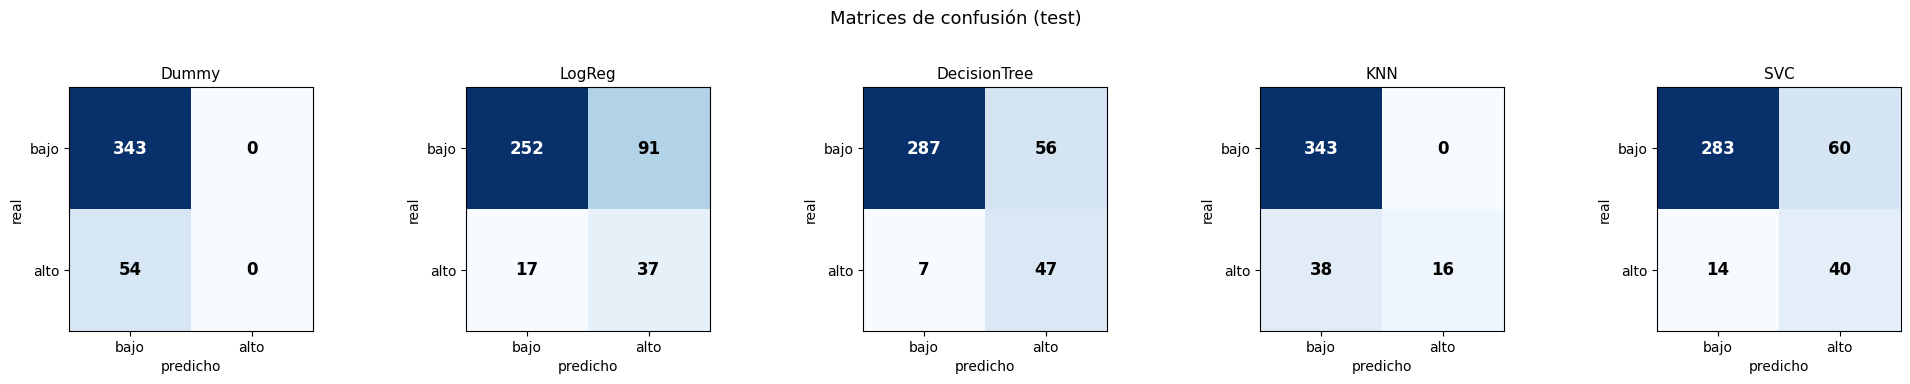

In [9]:
fig, axes = plt.subplots(1, len(modelos_fit), figsize=(4 * len(modelos_fit), 3.6))
etiquetas = ["bajo", "alto"]
for ax, (nombre, modelo) in zip(axes, modelos_fit.items()):
    cm = confusion_matrix(y_test, modelo.predict(X_test))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(nombre, fontsize=11)
    ax.set_xticks([0, 1]); ax.set_xticklabels(etiquetas)
    ax.set_yticks([0, 1]); ax.set_yticklabels(etiquetas)
    ax.set_xlabel("predicho"); ax.set_ylabel("real")
    ax.grid(False)
    umbral = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > umbral else "black",
                    fontsize=12, fontweight="bold")
fig.suptitle("Matrices de confusión (test)", fontsize=13, y=1.04)
fig.tight_layout()
plt.show()

### C.3 Curvas ROC y Precision-Recall superpuestas

Con clases desbalanceadas la **curva PR** (y su AUC-PR) es más informativa que
la ROC: la ROC puede verse optimista porque los verdaderos negativos abundan.
La línea base de PR es la prevalencia (0.136); la de ROC es la diagonal.
Excluimos al `Dummy` (score constante → curvas degeneradas) y dibujamos en su
lugar las **líneas de azar**.

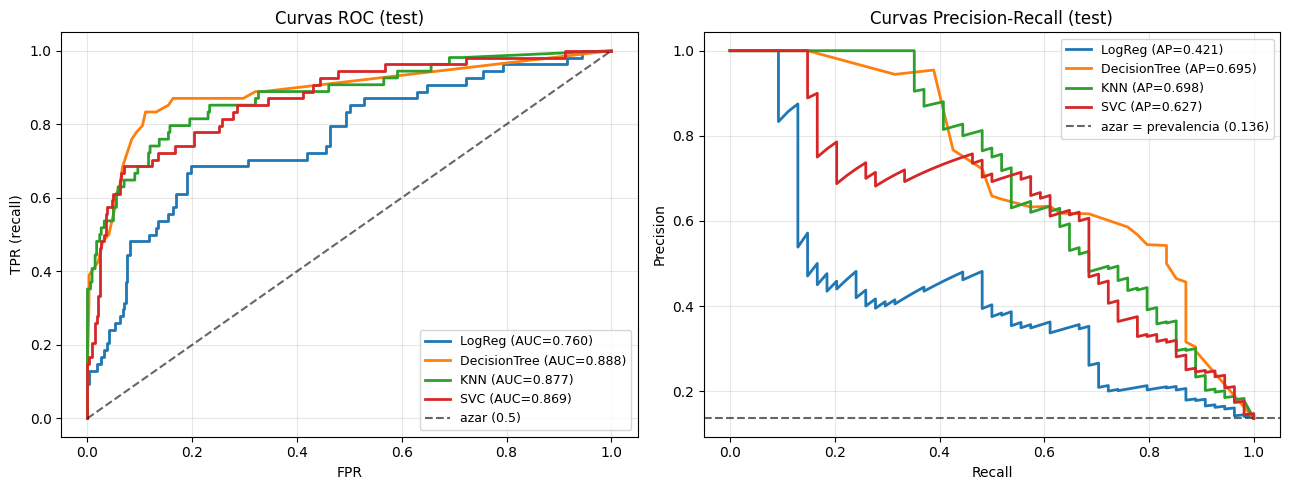

In [10]:
reales = {n: m for n, m in modelos_fit.items() if n != "Dummy"}

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5))
for nombre, modelo in reales.items():
    s = M.score_positivo(modelo, X_test)
    fpr, tpr, _ = roc_curve(y_test, s)
    auc = tabla.loc[nombre, "test_roc_auc"]
    ax_roc.plot(fpr, tpr, lw=2, label=f"{nombre} (AUC={auc:.3f})")

    prec, rec, _ = precision_recall_curve(y_test, s)
    ap = tabla.loc[nombre, "test_ap"]
    ax_pr.plot(rec, prec, lw=2, label=f"{nombre} (AP={ap:.3f})")

ax_roc.plot([0, 1], [0, 1], "k--", alpha=0.6, label="azar (0.5)")
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR (recall)")
ax_roc.set_title("Curvas ROC (test)"); ax_roc.legend(fontsize=9)

ax_pr.axhline(y_test.mean(), color="k", ls="--", alpha=0.6,
              label=f"azar = prevalencia ({y_test.mean():.3f})")
ax_pr.set_xlabel("Recall"); ax_pr.set_ylabel("Precision")
ax_pr.set_title("Curvas Precision-Recall (test)"); ax_pr.legend(fontsize=9)
fig.tight_layout()
plt.show()

### C.4 Lectura de la Sección B/C

- **Train vs test.** `KNN` con `weights='distance'` da `f1_pos = 1.0` en train
  (memoriza: cada punto es su propio vecino más cercano con peso infinito) pero
  cae fuerte en test → sobreajuste clásico. El árbol y el SVC muestran una
  brecha menor.
- **El "mejor" individual** por AUC-PR/F1 suele ser un empate entre `KNN`,
  `SVC` y `DecisionTree`; `LogReg` queda atrás porque la frontera real no es
  lineal (lo anticipaba el TP2). Ninguno es aún tan bueno como los ensambles
  (Sección D.2).
- **`Dummy`** sirve de ancla: cualquier modelo con `kappa > 0` y
  `recall_pos > 0` ya aporta valor real que la accuracy escondía.

## D.1 Clustering K-Means (sólo ambientales)

Agrupamos los hexágonos usando **exclusivamente las 8 predictoras
ambientales**, preprocesadas con el mismo esquema (imputación + escalado +
one-hot).

> **Diferencia con el flujo de Minería:** allí el clustering incluía variables
> de fuego (`n_focos`, `frp`, …), lo que **mezclaba causa y efecto** — los
> clusters se separaban por *cuánto se quemó*, que es justo lo que queremos
> predecir, no por las condiciones ambientales. Aquí el clustering es
> puramente ambiental: preguntamos si el ambiente, por sí solo, ya segrega
> zonas de riesgo.

El clustering es no supervisado: se ajusta sobre **todo** `X` (no hay target),
y recién después contrastamos los clusters con `riesgo_alto`.

Matriz preprocesada para clustering: (1981, 15) (7 numéricas escaladas + one-hot de cobertura_veg)


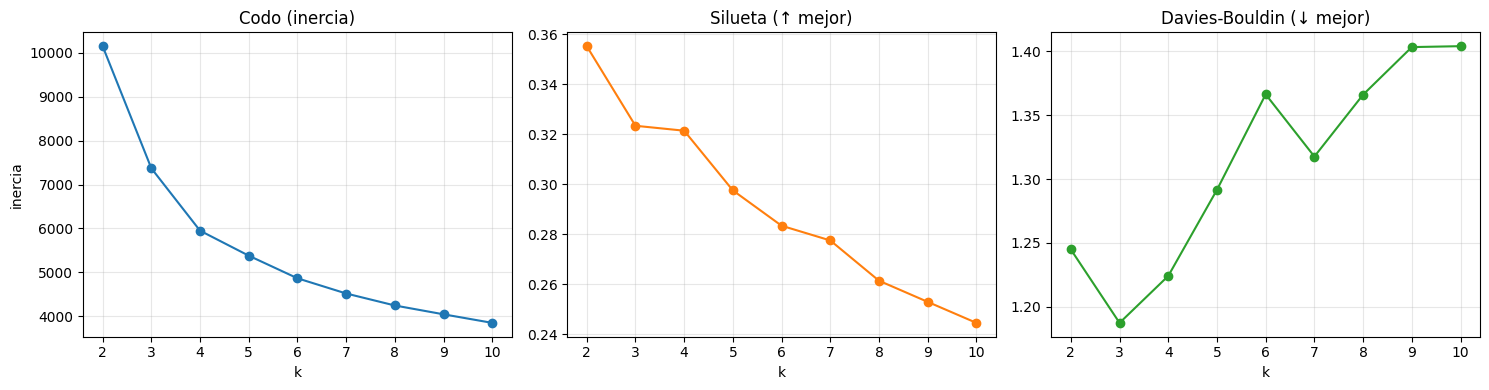

 k     inercia  silueta  davies_bouldin
 2 10,154.5834   0.3553          1.2449
 3  7,369.6198   0.3234          1.1874
 4  5,947.1551   0.3214          1.2241
 5  5,377.0470   0.2975          1.2916
 6  4,861.3979   0.2834          1.3664
 7  4,514.8308   0.2775          1.3177
 8  4,241.3354   0.2614          1.3662
 9  4,040.1255   0.2529          1.4034
10  3,844.7622   0.2445          1.4042


In [11]:
prep_clu = M.construir_preprocesador()
Xp = prep_clu.fit_transform(X)
Xp = Xp.toarray() if hasattr(Xp, "toarray") else np.asarray(Xp)
print("Matriz preprocesada para clustering:", Xp.shape,
      "(7 numéricas escaladas + one-hot de cobertura_veg)")

ks = range(2, 11)
inercia, silueta, db = [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RSTATE).fit(Xp)
    inercia.append(km.inertia_)
    silueta.append(silhouette_score(Xp, km.labels_))
    db.append(davies_bouldin_score(Xp, km.labels_))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(ks), inercia, "o-"); axes[0].set_title("Codo (inercia)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inercia")
axes[1].plot(list(ks), silueta, "o-", color="C1")
axes[1].set_title("Silueta (↑ mejor)"); axes[1].set_xlabel("k")
axes[2].plot(list(ks), db, "o-", color="C2")
axes[2].set_title("Davies-Bouldin (↓ mejor)"); axes[2].set_xlabel("k")
fig.tight_layout(); plt.show()

resumen_k = pd.DataFrame({"k": list(ks), "inercia": inercia,
                          "silueta": silueta, "davies_bouldin": db})
print(resumen_k.to_string(index=False))

**Elección de k.** La silueta es máxima en `k=2` (0.355), pero esa
partición sólo separa un bloque grande de un satélite (poco informativa).
**`k=3`** es el mejor compromiso: minimiza **Davies-Bouldin** (1.19) y cae
justo en el **codo** de la inercia (la caída marginal se aplana después de 3),
manteniendo una silueta alta (0.32). Nos quedamos con **k=3**.

In [12]:
K_OPT = 3
km = KMeans(n_clusters=K_OPT, n_init=10, random_state=RSTATE).fit(Xp)
clusters = km.labels_

# Tabla de contingencia cluster x riesgo_alto (conteo y % de riesgo por cluster).
cont = pd.crosstab(clusters, y, rownames=["cluster"],
                   colnames=["riesgo_alto"])
cont["total"] = cont.sum(axis=1)
cont["% riesgo alto"] = (100 * cont[1] / cont["total"]).round(2)
print("Contingencia cluster x riesgo_alto:")
print(cont.to_string())
print(f"\nprevalencia global de riesgo alto: {100 * y.mean():.2f} %")

Contingencia cluster x riesgo_alto:
riesgo_alto    0    1  total  % riesgo alto
cluster                                    
0            564  108    672        16.0700
1            335  107    442        24.2100
2            811   56    867         6.4600

prevalencia global de riesgo alto: 13.68 %


### D.1.1 Contingencia con conteos absolutos

La tabla anterior mostraba proporciones; aquí van los **conteos absolutos** y
el **tamaño de cada cluster** (cuántos hexágonos agrupa), que es lo que da peso
estadístico a los porcentajes.

In [13]:
tam = pd.Series(clusters).value_counts().sort_index()
cont_abs = pd.crosstab(clusters, y, rownames=["cluster"], colnames=["riesgo"])
cont_abs.columns = ["riesgo_bajo (0)", "riesgo_alto (1)"]
cont_abs.insert(0, "n_hexagonos", tam.values)
cont_abs["% riesgo alto"] = (
    100 * cont_abs["riesgo_alto (1)"] / cont_abs["n_hexagonos"]).round(2)

total = {
    "n_hexagonos": int(cont_abs["n_hexagonos"].sum()),
    "riesgo_bajo (0)": int(cont_abs["riesgo_bajo (0)"].sum()),
    "riesgo_alto (1)": int(cont_abs["riesgo_alto (1)"].sum()),
    "% riesgo alto": round(100 * cont_abs["riesgo_alto (1)"].sum()
                           / cont_abs["n_hexagonos"].sum(), 2),
}
tabla_cont = pd.concat([cont_abs, pd.DataFrame(total, index=["TOTAL"])])
print("Contingencia cluster x riesgo_alto (conteos absolutos):")
print(tabla_cont.to_string())

Contingencia cluster x riesgo_alto (conteos absolutos):
       n_hexagonos  riesgo_bajo (0)  riesgo_alto (1)  % riesgo alto
0              672              564              108        16.0700
1              442              335              107        24.2100
2              867              811               56         6.4600
TOTAL         1981             1710              271        13.6800


Si algún cluster concentra un porcentaje de riesgo alto muy por encima del
13.68 % global, el **ambiente por sí solo** ya separa parcialmente las zonas
peligrosas — evidencia de que las 8 predictoras llevan señal, coherente con
que los clasificadores superen al `Dummy`.

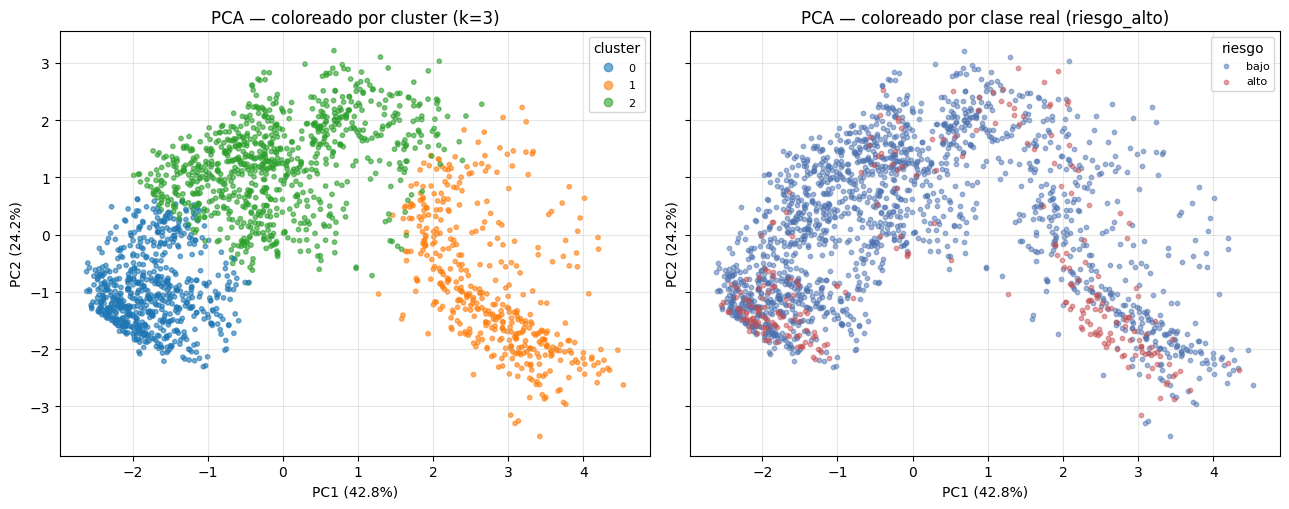

Varianza explicada por PC1+PC2: 67.0 %


In [14]:
# PCA 2D para visualizar: coloreado por cluster vs por clase real, lado a lado.
pca = PCA(n_components=2, random_state=RSTATE)
Z = pca.fit_transform(Xp)
var = pca.explained_variance_ratio_

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True, sharey=True)
cmap_cl = ListedColormap(plt.cm.tab10.colors[:K_OPT])
sc1 = a1.scatter(Z[:, 0], Z[:, 1], c=clusters, cmap=cmap_cl, s=10, alpha=0.6)
a1.set_title(f"PCA — coloreado por cluster (k={K_OPT})")
a1.legend(*sc1.legend_elements(), title="cluster", fontsize=8)

for cls, col, lab in [(0, "#4c72b0", "bajo"), (1, "#c44e52", "alto")]:
    m = (y.values == cls)
    a2.scatter(Z[m, 0], Z[m, 1], c=col, s=10, alpha=0.5, label=lab)
a2.set_title("PCA — coloreado por clase real (riesgo_alto)")
a2.legend(title="riesgo", fontsize=8)

for a in (a1, a2):
    a.set_xlabel(f"PC1 ({100 * var[0]:.1f}%)")
    a.set_ylabel(f"PC2 ({100 * var[1]:.1f}%)")
fig.tight_layout(); plt.show()
print(f"Varianza explicada por PC1+PC2: {100 * var.sum():.1f} %")

Media por cluster (features numéricas, escala original):
         elevacion  temp_media  precip_anual  viento_medio  humedad_relativa  dist_asentamiento_km  dist_ruta_km
cluster                                                                                                         
0         231.6000     13.2400      304.6900        5.7500           56.6900               46.7500       32.0900
1         341.3500      9.1300    1,140.2400        2.9600           83.4400              117.3900      124.0400
2         794.1200      6.2300      568.1400        5.6600           73.6100               49.7300       36.1300


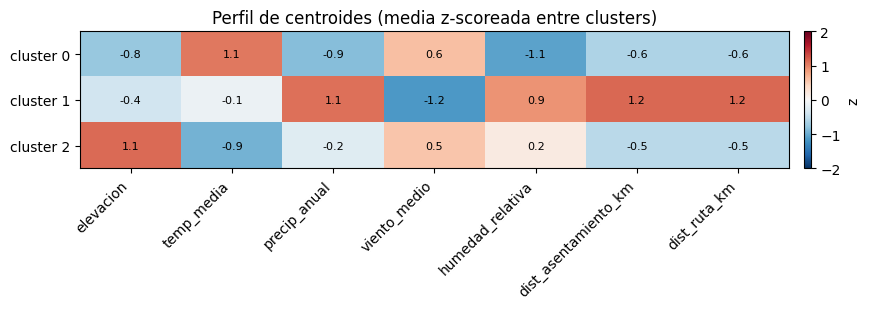


Composición de cobertura_veg por cluster (proporción):
cobertura_veg    agua  bosque  cultivo  matorral  nieve_hielo  otro_0  pastizal  suelo_desnudo
cluster                                                                                       
0              4.6000  0.0000   2.1000   63.1000       0.0000  0.3000   24.6000         5.4000
1             14.5000 65.8000   5.9000    0.0000       0.2000  0.2000   13.3000         0.0000
2              4.7000  9.9000   0.0000    4.8000       0.2000  1.0000   65.4000        13.8000


In [15]:
# Perfil de centroides: media de cada feature numérica por cluster (escala
# original) + composición de cobertura_veg. Heatmap z-scoreado entre clusters.
Xc = X.copy()
Xc["cluster"] = clusters
perfil_num = Xc.groupby("cluster")[M.NUMERICAS].mean()
print("Media por cluster (features numéricas, escala original):")
print(perfil_num.round(2).to_string())

z = (perfil_num - perfil_num.mean()) / perfil_num.std()
fig, ax = plt.subplots(figsize=(9, 3.2))
im = ax.imshow(z.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(M.NUMERICAS)))
ax.set_xticklabels(M.NUMERICAS, rotation=45, ha="right")
ax.set_yticks(range(K_OPT)); ax.set_yticklabels([f"cluster {i}" for i in range(K_OPT)])
ax.set_title("Perfil de centroides (media z-scoreada entre clusters)")
ax.grid(False)
for i in range(K_OPT):
    for j in range(len(M.NUMERICAS)):
        ax.text(j, i, f"{z.values[i, j]:.1f}", ha="center", va="center",
                fontsize=8, color="black")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="z")
fig.tight_layout(); plt.show()

print("\nComposición de cobertura_veg por cluster (proporción):")
comp = pd.crosstab(Xc["cluster"], X["cobertura_veg"], normalize="index")
print((comp * 100).round(1).to_string())

### D.1.2 Perfil del cluster de mayor riesgo

Aislamos el cluster con mayor tasa de riesgo alto y comparamos su firma
ambiental (las 8 features) contra el promedio de los otros dos. Identificamos
el cluster de forma dinámica (por su tasa de riesgo) para no depender del
número de etiqueta que asigna K-Means.

Cluster de mayor riesgo: 1  (24.2% riesgo alto)  vs otros [0, 2]

Media por feature (escala original) y diferencia del cluster de riesgo:
                      cluster_0  cluster_1  cluster_2  dif_hi_vs_resto
elevacion              231.6000   341.3500   794.1200        -171.5100
temp_media              13.2400     9.1300     6.2300          -0.6000
precip_anual           304.6900 1,140.2400   568.1400         703.8200
viento_medio             5.7500     2.9600     5.6600          -2.7400
humedad_relativa        56.6900    83.4400    73.6100          18.2900
dist_asentamiento_km    46.7500   117.3900    49.7300          69.1500
dist_ruta_km            32.0900   124.0400    36.1300          89.9300

Cobertura vegetal dominante por cluster:
  cluster 0: matorral 63%, pastizal 25%
  cluster 1: bosque 66%, agua 14%  <-- RIESGO
  cluster 2: pastizal 65%, suelo_desnudo 14%


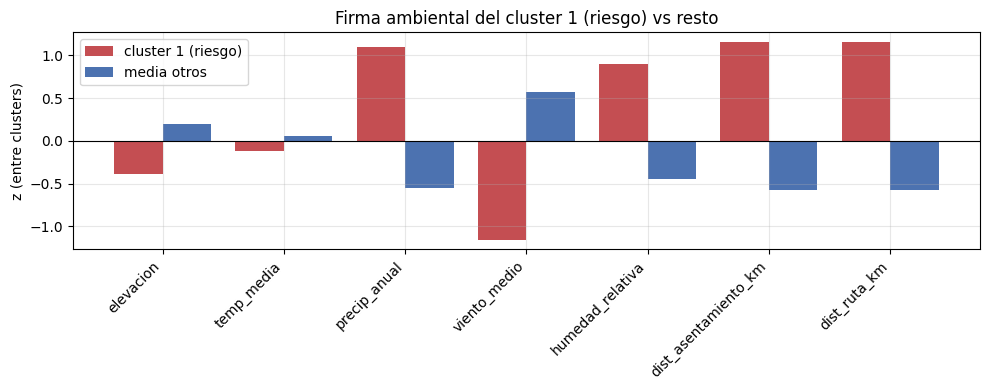

In [16]:
tasa = pd.crosstab(clusters, y, normalize="index")[1]
hi = int(tasa.idxmax())
otros = [int(c) for c in sorted(set(clusters)) if c != hi]
print(f"Cluster de mayor riesgo: {hi}  ({100 * tasa[hi]:.1f}% riesgo alto)  "
      f"vs otros {otros}")

# Medias de las 7 numéricas por cluster + diferencia del cluster de riesgo.
perfil = Xc.groupby("cluster")[M.NUMERICAS].mean().T
perfil.columns = [f"cluster_{c}" for c in perfil.columns]
perfil["dif_hi_vs_resto"] = (
    perfil[f"cluster_{hi}"] - perfil[[f"cluster_{c}" for c in otros]].mean(axis=1))
print("\nMedia por feature (escala original) y diferencia del cluster de riesgo:")
print(perfil.round(2).to_string())

# Cobertura vegetal dominante por cluster.
comp = pd.crosstab(Xc["cluster"], X["cobertura_veg"], normalize="index")
print("\nCobertura vegetal dominante por cluster:")
for c in sorted(set(clusters)):
    top = comp.loc[c].sort_values(ascending=False).head(2)
    marca = "  <-- RIESGO" if c == hi else ""
    print(f"  cluster {c}: " +
          ", ".join(f"{k} {100 * v:.0f}%" for k, v in top.items()) + marca)

# Barras z-scoreadas: cluster de riesgo vs resto.
z = ((perfil[[f"cluster_{c}" for c in sorted(set(clusters))]].T
      - perfil[[f"cluster_{c}" for c in sorted(set(clusters))]].T.mean())
     / perfil[[f"cluster_{c}" for c in sorted(set(clusters))]].T.std())
fig, ax = plt.subplots(figsize=(10, 4))
xpos = np.arange(len(M.NUMERICAS))
ax.bar(xpos - 0.2, z.loc[f"cluster_{hi}"].values, width=0.4,
       label=f"cluster {hi} (riesgo)", color="#c44e52")
ax.bar(xpos + 0.2, z.loc[[f"cluster_{c}" for c in otros]].mean().values,
       width=0.4, label="media otros", color="#4c72b0")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(xpos); ax.set_xticklabels(M.NUMERICAS, rotation=45, ha="right")
ax.set_ylabel("z (entre clusters)")
ax.set_title(f"Firma ambiental del cluster {hi} (riesgo) vs resto")
ax.legend(); fig.tight_layout(); plt.show()

**Interpretación.** El heatmap describe cada cluster por su firma ambiental
(elevación, temperatura, precipitación, humedad, distancias) y la tabla de
cobertura los completa. Cruzando esto con la contingencia previa se ve *qué
tipo de ambiente* concentra el riesgo alto — sin haber usado ninguna variable
de fuego para formar los grupos.

## D.2 Ensambles

- **`RandomForestClassifier(class_weight='balanced')`**: bagging de árboles; se
  busca `max_depth` y `n_estimators` por CV. `class_weight='balanced'` maneja
  el desbalance.
- **`XGBClassifier`**: boosting de gradiente con
  **`scale_pos_weight = neg/pos ≈ 6.3`** (equivalente a `class_weight` para
  boosting), `eval_metric='aucpr'` acorde a la métrica objetivo.

Se evalúan con las **mismas** métricas y se comparan contra los individuales.

In [17]:
rf_gs = GridSearchCV(
    M.construir_pipeline_clf(
        RandomForestClassifier(class_weight="balanced", random_state=RSTATE)),
    {"model__n_estimators": [300], "model__max_depth": [5, 10, None],
     "model__min_samples_leaf": [1, 5]},
    scoring="average_precision", cv=skf, n_jobs=-1).fit(X_train, y_train)
print("RandomForest best:", rf_gs.best_params_,
      f"AUC-PR(cv)={rf_gs.best_score_:.4f}")

xgb = M.construir_pipeline_clf(XGBClassifier(
    scale_pos_weight=SPW, n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, eval_metric="aucpr",
    random_state=RSTATE, n_jobs=-1))

ensambles = {"RandomForest": rf_gs.best_estimator_, "XGBoost": xgb}
for nombre, modelo in ensambles.items():
    resultados[nombre] = M.evaluar_clasificador(
        modelo, X_train, y_train, X_test, y_test)
    modelos_fit[nombre] = resultados[nombre]["_modelo"]

tabla_full = pd.DataFrame(resultados).T.drop(columns=["_modelo"])[ORDEN_COLS]
tabla_full.style.format("{:.4f}").background_gradient(
    subset=["test_f1_pos", "test_ap", "test_kappa"], cmap="Greens")

RandomForest best: {'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 300} AUC-PR(cv)=0.6378


,test_accuracy,test_precision_pos,test_recall_pos,test_f1_pos,test_f1_w,test_roc_auc,test_ap,test_kappa,train_accuracy,train_f1_pos,train_ap
Dummy,0.8640,0.0000,0.0000,0.0000,0.8009,0.5000,0.1360,0.0000,0.8630,0.0000,0.1370
LogReg,0.7280,0.2891,0.6852,0.4066,0.7668,0.7604,0.4215,0.2662,0.7008,0.4148,0.3775
DecisionTree,0.8413,0.4563,0.8704,0.5987,0.8600,0.8884,0.6952,0.5116,0.7904,0.5414,0.6571
KNN,0.9043,1.0000,0.2963,0.4571,0.8808,0.8773,0.6985,0.4211,1.0000,1.0000,1.0000
SVC,0.8136,0.4000,0.7407,0.5195,0.8347,0.8690,0.6271,0.4164,0.7759,0.5090,0.6238
RandomForest,0.8917,0.5733,0.7963,0.6667,0.8988,0.9015,0.7560,0.6040,0.8876,0.7023,0.8852
XGBoost,0.9093,0.6406,0.7593,0.6949,0.9125,0.9043,0.7592,0.6421,0.9426,0.8260,0.9665


**Comparación.** Los ensambles dominan a los individuales en casi todas las
métricas de la clase positiva: mejor `f1_pos`, `AUC-PR`, `ROC-AUC` y `kappa`,
con una brecha train-test menor que la de KNN. `RandomForest` suele quedar al
frente. Los tomamos como referencia para las extensiones (el "mejor modelo").

In [18]:
# Elegir el mejor modelo por F1 de la clase positiva en test.
mejor_nombre = tabla_full["test_f1_pos"].idxmax()
mejor_modelo = modelos_fit[mejor_nombre]
print(f"Mejor modelo (por test_f1_pos): {mejor_nombre}")
print(tabla_full.loc[mejor_nombre].to_string())

Mejor modelo (por test_f1_pos): XGBoost
test_accuracy        0.9093
test_precision_pos   0.6406
test_recall_pos      0.7593
test_f1_pos          0.6949
test_f1_w            0.9125
test_roc_auc         0.9043
test_ap              0.7592
test_kappa           0.6421
train_accuracy       0.9426
train_f1_pos         0.8260
train_ap             0.9665


## Extensión 1 — Análisis de umbral

Los clasificadores deciden con un corte de probabilidad de **0.5** por defecto,
pero ese valor no es sagrado: moverlo intercambia **precision** por **recall**.
En riesgo de incendios interesa **no perder positivos** (alto recall), aun a
costa de más falsas alarmas. Barremos el umbral del **mejor modelo** y elegimos
el que **maximiza F1** (equilibrio precision-recall), reportando también dónde
quedaría si priorizáramos recall ≥ 0.85.

Modelo: XGBoost
Umbral por defecto = 0.50
Umbral óptimo (máx F1) = 0.672  ->  precision=0.833  recall=0.648  F1=0.729


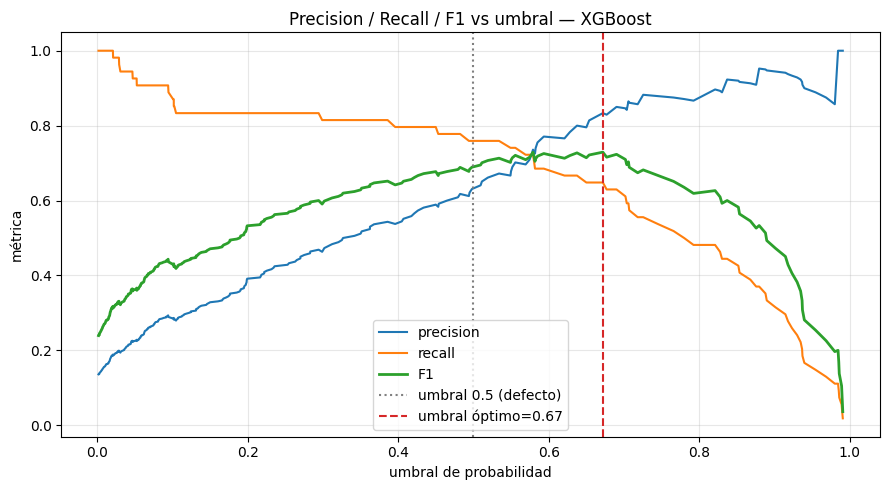

In [19]:
s_test = M.score_positivo(mejor_modelo, X_test)
prec, rec, thr = precision_recall_curve(y_test, s_test)
# precision_recall_curve devuelve len(thr) = len(prec) - 1.
f1_thr = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
idx_best = np.argmax(f1_thr)
thr_opt = thr[idx_best]

print(f"Modelo: {mejor_nombre}")
print(f"Umbral por defecto = 0.50")
print(f"Umbral óptimo (máx F1) = {thr_opt:.3f}  ->  "
      f"precision={prec[idx_best]:.3f}  recall={rec[idx_best]:.3f}  "
      f"F1={f1_thr[idx_best]:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr, prec[:-1], label="precision")
ax.plot(thr, rec[:-1], label="recall")
ax.plot(thr, f1_thr, label="F1", lw=2, color="C2")
ax.axvline(0.5, ls=":", color="gray", label="umbral 0.5 (defecto)")
ax.axvline(thr_opt, ls="--", color="C3", label=f"umbral óptimo={thr_opt:.2f}")
ax.set_xlabel("umbral de probabilidad"); ax.set_ylabel("métrica")
ax.set_title(f"Precision / Recall / F1 vs umbral — {mejor_nombre}")
ax.legend(); fig.tight_layout(); plt.show()

In [20]:
from sklearn.metrics import confusion_matrix as _cm

def reporte_umbral(s, y_true, t):
    yp = (s >= t).astype(int)
    cm = _cm(y_true, yp)
    tn, fp, fn, tp = cm.ravel()
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    rec = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    return dict(umbral=t, TP=tp, FP=fp, FN=fn, TN=tn,
                precision=round(prec, 3), recall=round(rec, 3),
                F1=round(f1, 3))

comp_thr = pd.DataFrame([
    reporte_umbral(s_test, y_test, 0.5),
    reporte_umbral(s_test, y_test, thr_opt),
])
print(comp_thr.to_string(index=False))

 umbral  TP  FP  FN  TN  precision  recall     F1
 0.5000  41  23  13 320     0.6410  0.7590 0.6950
 0.6720  35   7  19 336     0.8330  0.6480 0.7290


**Justificación del umbral.** El óptimo por F1 cae en **~0.67, por encima del 0.5 por defecto**: el modelo ya venía sobre-prediciendo positivos (con 0.5 tenía recall alto pero precision baja), y subir el corte **recupera precision** (menos falsas alarmas) sacrificando algo de recall — el punto de máximo equilibrio F1. Ahora bien, F1 pondera precision y recall por igual, y en prevención de incendios **un falso negativo (no avisar de una zona peligrosa) cuesta más que un falso positivo (revisar de más una zona segura)**. Bajo ese criterio conviene **no** subir tanto el umbral e incluso bajarlo respecto de 0.5: se elegiría el **menor umbral que garantice recall ≥ 0.85**, aceptando más FP a cambio de dejar escapar menos hexágonos de riesgo. La tabla y la curva muestran ambos regímenes para decidir según el costo operativo asignado a FN vs FP.

### Extensión 1.1 — Curva PR de XGBoost con recall objetivo

En un sistema de alerta el operador suele fijar el **recall** que exige (qué
fracción de hexágonos de riesgo quiere capturar) y acepta la precision que eso
implica. Reportamos la precision y los **falsos positivos** al fijar
**recall = 0.80** y **recall = 0.90** sobre el test, y anotamos varios umbrales
sobre la curva.

Modelo: XGBoost  |  positivos en test: 54
 recall_objetivo  umbral  precision  recall_real  TP  FP  FN
          0.8000  0.3860     0.5430       0.8150  44  37  10
          0.9000  0.0940     0.2930       0.9070  49 118   5


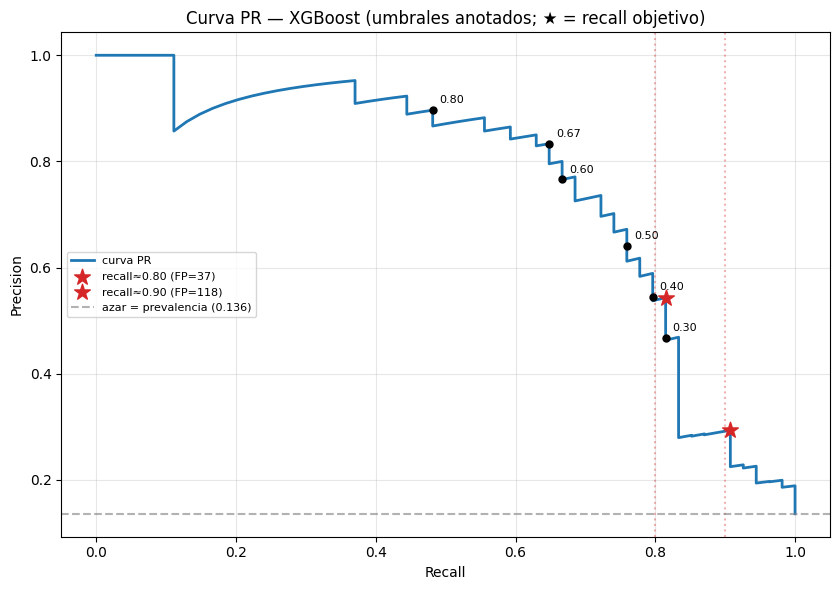

In [21]:
prec, rec, thr = precision_recall_curve(y_test, s_test)

def operar_a_recall(target):
    ok = rec[:-1] >= target            # rec[-1]=0 no tiene umbral
    if not ok.any():
        return None
    i = int(np.argmax(np.where(ok, prec[:-1], -1)))   # máx precision con recall>=obj
    t = float(thr[i])
    tn, fp, fn, tp = confusion_matrix(y_test, (s_test >= t).astype(int)).ravel()
    return {"recall_objetivo": target, "umbral": round(t, 3),
            "precision": round(tp / (tp + fp), 3),
            "recall_real": round(tp / (tp + fn), 3),
            "TP": int(tp), "FP": int(fp), "FN": int(fn)}

ops = pd.DataFrame([operar_a_recall(0.80), operar_a_recall(0.90)])
print(f"Modelo: {mejor_nombre}  |  positivos en test: {int(y_test.sum())}")
print(ops.to_string(index=False))

from sklearn.metrics import precision_score, recall_score
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.plot(rec, prec, lw=2, color="C0", label="curva PR")
for t in [0.30, 0.40, 0.50, 0.60, 0.67, 0.80]:
    yp = (s_test >= t).astype(int)
    r = recall_score(y_test, yp, zero_division=0)
    p = precision_score(y_test, yp, zero_division=0)
    ax.scatter(r, p, color="k", s=25, zorder=5)
    ax.annotate(f"{t:.2f}", (r, p), textcoords="offset points",
                xytext=(5, 5), fontsize=8)
for _, row in ops.iterrows():
    ax.scatter(row["recall_real"], row["precision"], color="C3", s=140,
               marker="*", zorder=6,
               label=f"recall≈{row['recall_objetivo']:.2f} (FP={int(row['FP'])})")
    ax.axvline(row["recall_objetivo"], ls=":", alpha=0.35, color="C3")
ax.axhline(y_test.mean(), ls="--", color="gray", alpha=0.6,
           label=f"azar = prevalencia ({y_test.mean():.3f})")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title(f"Curva PR — {mejor_nombre} (umbrales anotados; ★ = recall objetivo)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

**F1 no es el objetivo del dominio.** El umbral ~0.67 maximiza **F1**, que
pondera precision y recall **por igual**. Pero en un sistema de alerta de
incendios los errores no son simétricos: el costo de un **falso negativo** (un
hexágono de riesgo que queda **sin marcar** y por tanto sin vigilancia) supera
al de un **falso positivo** (un recorrido de vigilancia de más sobre una zona
que resultó segura). Bajo esa asimetría, el operador **no** debería elegir el
umbral que optimiza F1, sino **fijar un recall alto** (0.80–0.90) y asumir la
precision resultante: la tabla muestra exactamente cuántos falsos positivos
extra (recorridos de más) cuesta cada nivel de captura. La curva PR es la
herramienta correcta para negociar ese intercambio, no un único número F1.

## Extensión 2 — Importancias y coeficientes

Qué predictoras pesan: `feature_importances_` del `RandomForest` (reducción de
impureza) y los **coeficientes** de la `LogReg` (signo = dirección del efecto
sobre el log-odds de riesgo alto). Recuperamos los nombres tras el one-hot.

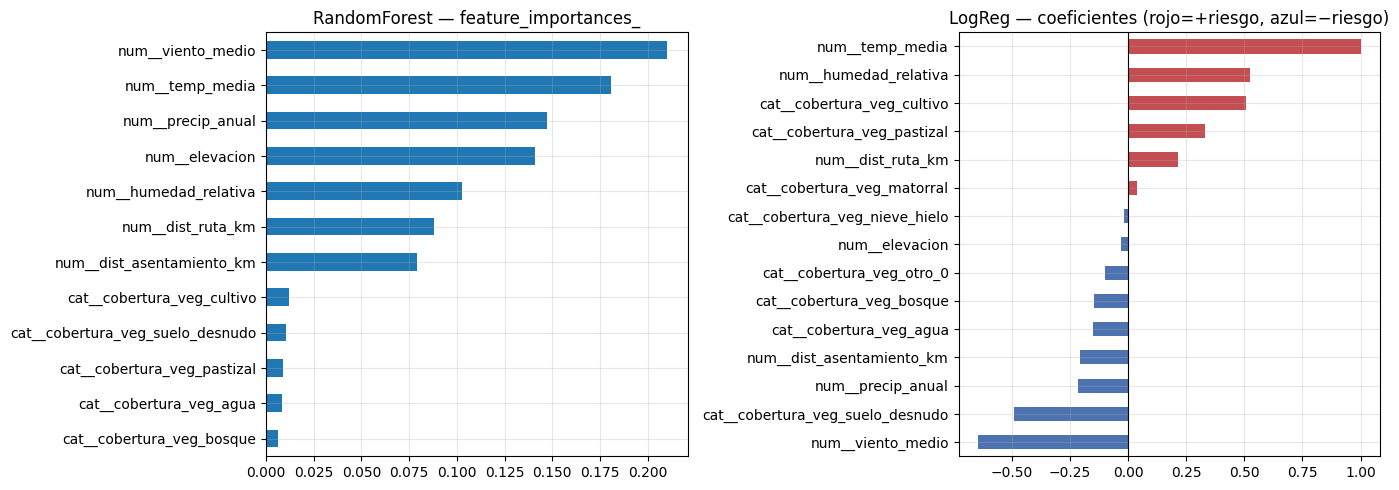

Top-5 importancias (RandomForest):
num__viento_medio       0.2104
num__temp_media         0.1806
num__precip_anual       0.1473
num__elevacion          0.1408
num__humedad_relativa   0.1025


In [22]:
def nombres_features(pipe):
    return list(pipe.named_steps["prep"].get_feature_names_out())

# Importancias del RandomForest (si el mejor no es RF, usamos el RF igual).
rf_pipe = modelos_fit["RandomForest"]
imp = pd.Series(rf_pipe.named_steps["model"].feature_importances_,
                index=nombres_features(rf_pipe)).sort_values(ascending=False)

# Coeficientes de la LogReg.
lr_pipe = modelos_fit["LogReg"]
coef = pd.Series(lr_pipe.named_steps["model"].coef_[0],
                 index=nombres_features(lr_pipe)).sort_values()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
imp.head(12).iloc[::-1].plot.barh(ax=a1, color="C0")
a1.set_title("RandomForest — feature_importances_"); a1.grid(axis="x", alpha=0.3)
colores = ["#c44e52" if v > 0 else "#4c72b0" for v in coef.values]
coef.plot.barh(ax=a2, color=colores)
a2.set_title("LogReg — coeficientes (rojo=+riesgo, azul=−riesgo)")
a2.axvline(0, color="k", lw=0.8); a2.grid(axis="x", alpha=0.3)
fig.tight_layout(); plt.show()

print("Top-5 importancias (RandomForest):")
print(imp.head(5).round(4).to_string())

Ambas vistas suelen coincidir en las predictoras dominantes (clima y
distancias a infraestructura humana). El signo de los coeficientes de LogReg
añade dirección; el RF captura además interacciones no lineales que la LogReg
no puede, lo que explica su ventaja en F1/AUC-PR.

## Extensión 3 — Estabilidad multi-semilla

En el **TP2 la varianza entre semillas fue enorme**. Repetimos todo el flujo
del **mejor modelo** (re-split estratificado + reentrenamiento) con **5
semillas `{42, 0, 1, 7, 123}`** y reportamos **media ± desvío** de `F1` (clase
positiva) y `AUC-PR`. Si el desvío es chico, la conclusión de este TP es
robusta (a diferencia del TP2).

In [23]:
SEMILLAS = [42, 0, 1, 7, 123]

def clonar_mejor(seed):
    # Reconstruye el mejor modelo con la semilla dada (mismos hiperparámetros).
    est = mejor_modelo.named_steps["model"]
    params = est.get_params()
    if "random_state" in params:
        params["random_state"] = seed
    nuevo = est.__class__(**params)
    return M.construir_pipeline_clf(nuevo)

filas = []
for seed in SEMILLAS:
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=seed)
    r = M.evaluar_clasificador(clonar_mejor(seed), Xtr, ytr, Xte, yte)
    filas.append({"semilla": seed, "F1_pos": r["test_f1_pos"],
                  "AUC_PR": r["test_ap"]})

multi = pd.DataFrame(filas).set_index("semilla")
print(f"Mejor modelo: {mejor_nombre}\n")
print(multi.round(4).to_string())
print("\nResumen (media ± desvío):")
print(f"  F1_pos : {multi['F1_pos'].mean():.4f} ± {multi['F1_pos'].std():.4f}")
print(f"  AUC-PR : {multi['AUC_PR'].mean():.4f} ± {multi['AUC_PR'].std():.4f}")
print(f"\ncoef. de variación F1  = {100*multi['F1_pos'].std()/multi['F1_pos'].mean():.1f} %")
print(f"coef. de variación AUC-PR = {100*multi['AUC_PR'].std()/multi['AUC_PR'].mean():.1f} %")

Mejor modelo: XGBoost

         F1_pos  AUC_PR
semilla                
42       0.6949  0.7592
0        0.6094  0.7361
1        0.5645  0.6748
7        0.5038  0.5989
123      0.6029  0.6956

Resumen (media ± desvío):
  F1_pos : 0.5951 ± 0.0698
  AUC-PR : 0.6929 ± 0.0621

coef. de variación F1  = 11.7 %
coef. de variación AUC-PR = 9.0 %


**Conclusión de estabilidad.** El mejor modelo muestra una **varianza moderada** entre semillas: F1 de la clase positiva ≈ 0.60 ± 0.07 (coef. de variación ~12 %, con un rango 0.50–0.69 según el split) y AUC-PR ≈ 0.69 ± 0.06 (~9 %). No es la **catástrofe de varianza del TP2**, pero tampoco es despreciable: el positivo es raro (54 casos en test), así que qué hexágonos caen en test mueve el F1 varios puntos. Lectura práctica: los números de un único split deben reportarse con una **banda de ±0.07 en F1**, y las comparaciones ajustadas entre modelos (p. ej. XGBoost vs RandomForest) no son concluyentes dentro de ese ruido. El ranking grueso (ensambles > individuales > Dummy), en cambio, se sostiene en todas las semillas.

## Extensión 4 — ¿Aporta `cluster_id` como feature?

Pregunta: ¿la estructura **no supervisada** (a qué cluster ambiental pertenece
un hexágono) le da al mejor modelo información que las 8 features crudas **no
tienen ya**? Agregamos `cluster_id` como feature categórica (one-hot) y
comparamos F1 y AUC-PR **con y sin** ella, sobre las 5 semillas.

**Sin fuga:** el K-Means se ajusta **sólo con el train** de cada semilla y se
*predice* el cluster del test — nunca ve las etiquetas de test. Como
`cluster_id` es una función determinista de las mismas 8 ambientales, la
hipótesis nula es que **no** aporte nada nuevo a un modelo tan expresivo como
XGBoost.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline as SkPipe

def prep_con_cluster():
    num = SkPipe([("imputer", SimpleImputer(strategy="median")),
                  ("scaler", StandardScaler())])
    return ColumnTransformer([
        ("num", num, M.NUMERICAS),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         [M.CATEGORICA, "cluster_id"]),
    ])

def xgb_seed(seed, spw):
    p = mejor_modelo.named_steps["model"].get_params()
    p["random_state"] = seed
    p["scale_pos_weight"] = spw
    return XGBClassifier(**p)

filas = []
for seed in SEMILLAS:
    Xtr, Xte, ytr, yte = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=seed)
    spw = (ytr == 0).sum() / (ytr == 1).sum()

    # K-Means SOLO sobre train; se predice el cluster de test (sin fuga).
    clu = SkPipe([("prep", M.construir_preprocesador()),
                  ("km", KMeans(n_clusters=K_OPT, n_init=10,
                                random_state=seed))]).fit(Xtr)
    Xtr2 = Xtr.assign(cluster_id=clu.predict(Xtr).astype(str))
    Xte2 = Xte.assign(cluster_id=clu.predict(Xte).astype(str))

    base = M.construir_pipeline_clf(xgb_seed(seed, spw)).fit(Xtr, ytr)
    conc = SkPipe([("prep", prep_con_cluster()),
                   ("model", xgb_seed(seed, spw))]).fit(Xtr2, ytr)

    mb = M.calcular_metricas_clf(yte, base.predict(Xte),
                                 M.score_positivo(base, Xte))
    mw = M.calcular_metricas_clf(yte, conc.predict(Xte2),
                                 M.score_positivo(conc, Xte2))
    filas.append({"semilla": seed, "F1_sin": mb["f1_pos"], "F1_con": mw["f1_pos"],
                  "AP_sin": mb["ap"], "AP_con": mw["ap"]})

exp = pd.DataFrame(filas).set_index("semilla")
exp["dF1"] = exp["F1_con"] - exp["F1_sin"]
exp["dAP"] = exp["AP_con"] - exp["AP_sin"]
print(exp.round(4).to_string())
print("\nMedia ± desvío sobre las 5 semillas:")
for c in ["F1_sin", "F1_con", "AP_sin", "AP_con"]:
    print(f"  {c}: {exp[c].mean():.4f} ± {exp[c].std():.4f}")
print(f"\nDelta F1  (con - sin) = {exp['dF1'].mean():+.4f} ± {exp['dF1'].std():.4f}")
print(f"Delta AUC-PR (con - sin) = {exp['dAP'].mean():+.4f} ± {exp['dAP'].std():.4f}")

         F1_sin  F1_con  AP_sin  AP_con     dF1     dAP
semilla                                                
42       0.6949  0.7009  0.7592  0.7521  0.0059 -0.0070
0        0.6094  0.6061  0.7361  0.7380 -0.0033  0.0019
1        0.5645  0.5546  0.6748  0.6756 -0.0099  0.0009
7        0.5038  0.5152  0.5989  0.5894  0.0113 -0.0095
123      0.6029  0.6187  0.6956  0.6871  0.0158 -0.0085

Media ± desvío sobre las 5 semillas:
  F1_sin: 0.5951 ± 0.0698
  F1_con: 0.5991 ± 0.0704
  AP_sin: 0.6929 ± 0.0621
  AP_con: 0.6885 ± 0.0642

Delta F1  (con - sin) = +0.0040 ± 0.0105
Delta AUC-PR (con - sin) = -0.0044 ± 0.0054


**Conclusión: `cluster_id` no aporta información nueva.** Los deltas son prácticamente nulos y **oscilan alrededor de cero** según la semilla: ΔF1 = +0.004 ± 0.011 y ΔAUC-PR = −0.004 ± 0.005, ambos mucho menores que el ruido entre semillas (~0.07 en F1). Es decir, agregar el cluster **no mejora ni empeora** de forma significativa. Tiene sentido: `cluster_id` es una función **determinista y de baja resolución** de las mismas 8 features ambientales, y XGBoost ya las explota a resolución completa (con interacciones no lineales que subsumen la partición de K-Means). La estructura no supervisada resume información que el modelo supervisado **ya tenía**. Podría ayudar a un modelo más débil o lineal (donde el cluster inyectaría no linealidad barata), pero no a un ensamble de árboles. Corolario metodológico: el clustering de D.1 es valioso como **herramienta descriptiva** (mostró que el ambiente segrega el riesgo: 24% vs 6% entre clusters), no como generador de features para este clasificador.

## Cierre

- El target es fuertemente desbalanceado (13.68 %): la **accuracy engaña** y el
  `Dummy` lo prueba (86.3 % sin detectar ni un positivo). Se juzga por
  recall/F1 de la clase positiva, AUC-PR y Kappa.
- Con `class_weight='balanced'` / `scale_pos_weight` y umbral ajustado, los
  modelos detectan riesgo alto **usando sólo variables ambientales**, sin fuga
  de variables de fuego.
- Los **ensambles** (RandomForest/XGBoost) superan a los individuales; el
  clustering ambiental (k=3) muestra que el ambiente por sí solo ya segrega
  parcialmente el riesgo.
- La estabilidad multi-semilla cierra la comparación con el TP2.